import and load filtered data

In [4]:
import sys
sys.path.append('../src')
from embedder import load_embedding_model, generate_embeddings, build_faiss_index, save_vector_store
from chunker import stratified_sample, build_splitter, chunk_complaints

import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('../src')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f"Loaded: {len(df):,} complaints")
print(df['product_category'].value_counts())

Loaded: 423,913 complaints
product_category
Savings Account    155158
Money Transfer      98676
Credit Card         88440
Personal Loan       81639
Name: count, dtype: int64


stratified sample

In [5]:
sample_df = stratified_sample(df, n=12000, random_state=42)

Stratified sample: 12,000 rows

Sample distribution:
product_category
Savings Account    4392
Money Transfer     2793
Credit Card        2504
Personal Loan      2311
Name: count, dtype: int64

Original distribution (%):
product_category
Savings Account    36.6
Money Transfer     23.3
Credit Card        20.9
Personal Loan      19.3
Name: count, dtype: float64

Sample distribution (%):
product_category
Savings Account    36.6
Money Transfer     23.3
Credit Card        20.9
Personal Loan      19.3
Name: count, dtype: float64


visualize sample vs full distribution

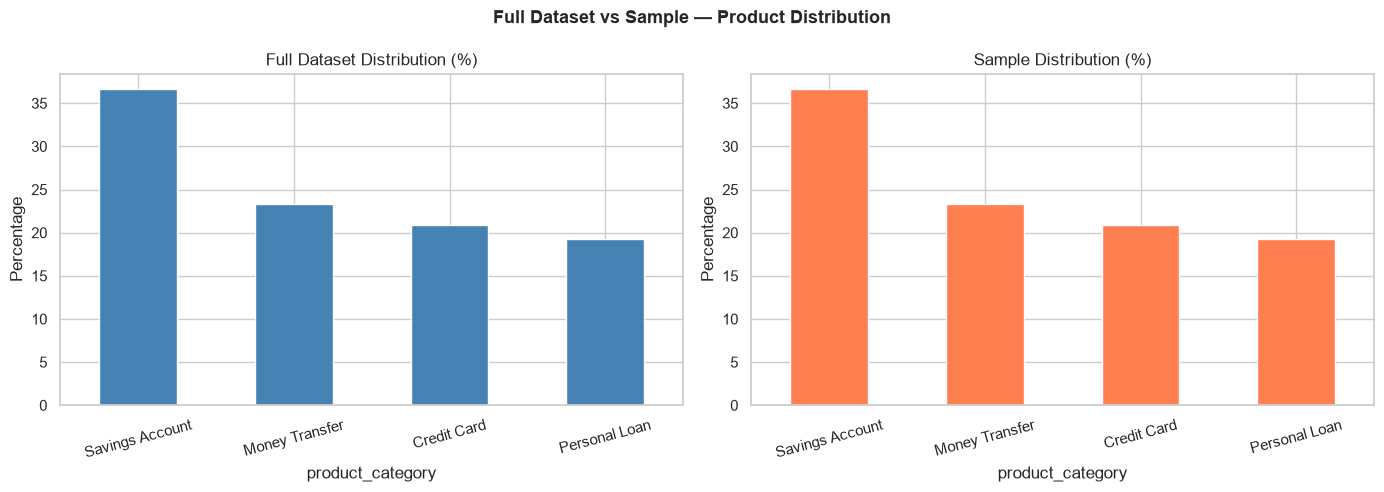

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['product_category'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Full Dataset Distribution (%)')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=15)

sample_df['product_category'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Sample Distribution (%)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Full Dataset vs Sample — Product Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=150)
plt.show()

build splitter an chuck

In [7]:
splitter = build_splitter(chunk_size=500, chunk_overlap=50)
chunks_df = chunk_complaints(sample_df, splitter)

print(f"\nChunks DataFrame shape: {chunks_df.shape}")
chunks_df.head(3)

Splitter built — chunk_size=500, chunk_overlap=50
Produced 35,831 chunks from 12,000 complaints
Avg chunks per complaint: 3.0

Chunks DataFrame shape: (35831, 11)


,complaint_id,date_received,product,product_category,issue,sub_issue,company,state,chunk_text,chunk_index,total_chunks
0,7822971,2023-11-07,Checking or savings account,Savings Account,Managing an account,Banking errors,"BANK OF AMERICA, NATIONAL ASSOCIATION",VA,", i spent 1200.00 for my rent and 460.00 for a...",0,3
1,7822971,2023-11-07,Checking or savings account,Savings Account,Managing an account,Banking errors,"BANK OF AMERICA, NATIONAL ASSOCIATION",VA,". today, , i still have not received the reimb...",1,3
2,7822971,2023-11-07,Checking or savings account,Savings Account,Managing an account,Banking errors,"BANK OF AMERICA, NATIONAL ASSOCIATION",VA,. i have an email from my leasing office for t...,2,3


chunck stats

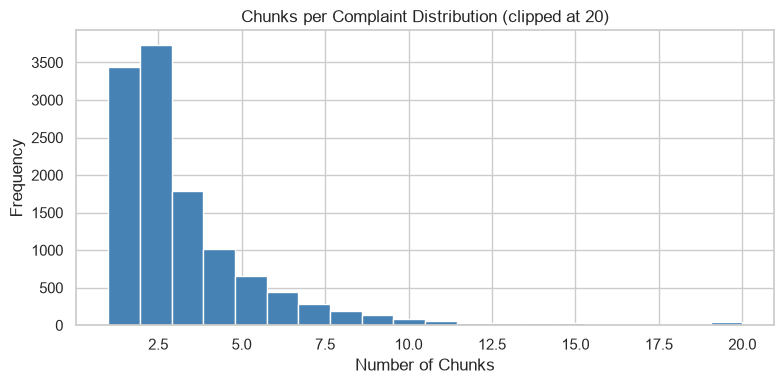

Avg chunks per complaint : 3.0
Max chunks per complaint : 90
Total chunks             : 35,831


In [8]:
chunk_counts = chunks_df.groupby('complaint_id')['chunk_index'].max() + 1

fig, ax = plt.subplots(figsize=(8, 4))
chunk_counts.clip(upper=20).hist(
    bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Chunks per Complaint Distribution (clipped at 20)')
ax.set_xlabel('Number of Chunks')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Avg chunks per complaint : {chunk_counts.mean():.1f}")
print(f"Max chunks per complaint : {chunk_counts.max()}")
print(f"Total chunks             : {len(chunks_df):,}")

sample chunck output

In [9]:
print("=== Sample Chunk ===")
sample_chunk = chunks_df.iloc[0]
print(f"complaint_id   : {sample_chunk['complaint_id']}")
print(f"product_category: {sample_chunk['product_category']}")
print(
    f"chunk_index    : {sample_chunk['chunk_index']} / {sample_chunk['total_chunks']}")
print(f"chunk_text     :\n{sample_chunk['chunk_text']}")

=== Sample Chunk ===
complaint_id   : 7822971
product_category: Savings Account
chunk_index    : 0 / 3
chunk_text     :
, i spent 1200.00 for my rent and 460.00 for a firearm on both payments were denied, and i had to call bank of america to confirm the payments and unlock my card. the customer support said the failed transactions would be reimbursed 1-3 business days after they are fully processed. after my card was unlocked, i made the 460.00 payment again. i still haven't received the reimbursement, but made the 1200.00 payment again to avoid late fees or potential eviction


load model and embed

In [10]:
model = load_embedding_model()
embeddings = generate_embeddings(chunks_df, model, batch_size=64)

print(f"\nEmbeddings shape : {embeddings.shape}")
print(f"Dtype            : {embeddings.dtype}")
print(f"Sample norms     : {(embeddings[:5] ** 2).sum(axis=1).round(4)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3541.50it/s]


Loaded embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimensions: 384
Embedding 35,831 chunks in batches of 64...


Batches: 100%|██████████| 560/560 [09:20<00:00,  1.00s/it]


Embeddings shape: (35831, 384)

Embeddings shape : (35831, 384)
Dtype            : float32
Sample norms     : [1. 1. 1. 1. 1.]


build index and save

In [11]:
index = build_faiss_index(embeddings)
save_vector_store(index, chunks_df, out_dir='../vector_store')

FAISS index built — 35,831 vectors, 384 dimensions
FAISS index saved  : ../vector_store\faiss_index.bin
Metadata saved     : ../vector_store\chunk_metadata.pkl
